# 2D Pipeline Data Exploration

This notebook explores the repository's 2D per-slice pipeline end-to-end, with a focus on:

- How `create_dataset_2d` expands each volume into one sample per tumor slice.
- How `_build_2d_pipeline` transforms a sample from NIfTI paths to `(1, H, W)` tensors.
- Whether collation, model forward, and volume/patient aggregation behavior match `training/train_2d.py`.

The notebook intentionally mirrors project code paths in:

- `data/dataset_2d.py`
- `data/transforms.py`
- `training/train_2d.py`

Run top-to-bottom. Some sections are optional and can be toggled with config flags if runtime is heavy.

## 0) Environment Setup and Imports

This section imports dependencies, sets deterministic seeds, and configures plotting defaults.

In [14]:
import copy
import json
import os
import random
import warnings
from collections import Counter, defaultdict
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from monai.data import Dataset
from torch.utils.data import DataLoader

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)

# Make project root import-safe when launched from data_exploration/
REPO_ROOT = Path("/home/hansstem/SCLC-Classification")
if str(REPO_ROOT) not in os.sys.path:
    os.sys.path.insert(0, str(REPO_ROOT))

from data.data_loader import CLASS_NAMES
from data.dataset_2d import (
    _expand_volume_entries_to_slices,
    _scan_tumor_slice_indices,
    create_dataset_2d,
    get_biglunge_2d_data_list,
    get_lung_pet_ct_dx_2d_data_list,
)
from data.transforms import _build_2d_pipeline, get_train_transforms_2d, get_val_transforms_2d
from model_selection import get_sclc_model
from training.train import _compute_classification_metrics
from training.train_2d import simple_collate_fn_2d


def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(42)
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Repo root: {REPO_ROOT}")

PyTorch: 2.10.0+cu128
CUDA available: True
Repo root: /home/hansstem/SCLC-Classification


In [15]:
# ----- Config -----
# Toggle between "big_lunge" and "lung_pet_ct_dx".
DATASET_TYPE = "lung_pet_ct_dx"

# Main defaults follow main.py conventions.
DEFAULT_PATHS = {
    "big_lunge": {
        "data_path": "/home/data/TrainingData",
        "csv_path": "/home/data/TrainingData/patients_parameters.csv",
    },
    "lung_pet_ct_dx": {
        "data_path": "/home/data/Lung-PET-CT-Dx-Clean",
        "csv_path": "",
    },
}

CFG: Dict[str, Any] = {
    "dataset_type": DATASET_TYPE,
    "data_path": DEFAULT_PATHS[DATASET_TYPE]["data_path"],
    "csv_path": DEFAULT_PATHS[DATASET_TYPE]["csv_path"],
    "img_size": 224,
    "tumor_mask_suffix": "_label_tumor.nii.gz",
    "min_tumor_pixels": 1,
    "max_slices_per_volume": 8,   # set <=0 for no cap
    "val_frac": 0.15,
    "test_frac": 0.15,
    "seed": 42,
    "testing": True,              # True is faster for exploration
    "cache_workers": 4,
    "warm_cache": False,
    "batch_size": 8,
    "num_workers": 0,
    "max_batches_eval": 4,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
}

MAX_SLICES = CFG["max_slices_per_volume"]
MAX_SLICES = None if (MAX_SLICES is None or MAX_SLICES <= 0) else int(MAX_SLICES)

cache_name = "monai_biglunge_2d" if CFG["dataset_type"] == "big_lunge" else "monai_lung_pet_ct_clean_2d"
CACHE_ROOT = os.path.join(
    os.path.expanduser("~"),
    ".cache",
    cache_name,
    f"img{CFG['img_size']}{'_testing' if CFG['testing'] else ''}",
)
TUMOR_INDEX_PATH = os.path.join(CACHE_ROOT, "tumor_slice_index.json")

print(pd.Series(CFG))
print(f"Cache root: {CACHE_ROOT}")
print(f"Tumor index path: {TUMOR_INDEX_PATH}")

if not os.path.isdir(CFG["data_path"]):
    print("WARNING: data_path does not exist. Update CFG['data_path'] before running heavy cells.")
if CFG["dataset_type"] == "big_lunge" and CFG["csv_path"] and not os.path.isfile(CFG["csv_path"]):
    print("WARNING: csv_path does not exist. Update CFG['csv_path'] before dataset creation.")

dataset_type                              lung_pet_ct_dx
data_path                /home/data/Lung-PET-CT-Dx-Clean
csv_path                                                
img_size                                             224
tumor_mask_suffix                    _label_tumor.nii.gz
min_tumor_pixels                                       1
max_slices_per_volume                                  8
val_frac                                            0.15
test_frac                                           0.15
seed                                                  42
testing                                             True
cache_workers                                          4
warm_cache                                         False
batch_size                                             8
num_workers                                            0
max_batches_eval                                       4
device                                              cuda
dtype: object
Cache root: /home

## 1) Load 2D Dataset Splits with create_dataset_2d

This section instantiates the exact `PersistentDataset` objects used by training for the 2D pipeline and records split/cache details.

In [16]:
train_ds = val_ds = test_ds = None
split_to_ds: Dict[str, Any] = {}

if os.path.isdir(CFG["data_path"]) and (CFG["dataset_type"] != "big_lunge" or os.path.isfile(CFG["csv_path"])):
    train_ds, val_ds, test_ds = create_dataset_2d(
        data_path=CFG["data_path"],
        csv_path=CFG["csv_path"],
        dataset_type=CFG["dataset_type"],
        img_size=CFG["img_size"],
        tumor_mask_suffix=CFG["tumor_mask_suffix"],
        max_slices_per_volume=MAX_SLICES,
        min_tumor_pixels=int(CFG["min_tumor_pixels"]),
        val_frac=float(CFG["val_frac"]),
        test_frac=float(CFG["test_frac"]),
        seed=int(CFG["seed"]),
        testing=bool(CFG["testing"]),
        warm_cache=bool(CFG["warm_cache"]),
        cache_workers=int(CFG["cache_workers"]),
    )

    split_to_ds = {"train": train_ds, "val": val_ds, "test": test_ds}
    split_sizes = {k: len(v) for k, v in split_to_ds.items()}

    print("Dataset build complete.")
    print(f"Split sizes (slices): {split_sizes}")
    for split in ("train", "val", "test"):
        split_cache = os.path.join(CACHE_ROOT, split)
        print(f"{split:>5} cache -> {split_cache}")
else:
    print("Skipped dataset creation: check data path / csv path in CFG.")

Split 'train': 242 patients.
  12 images (12 w/ masks), class distribution: {2: 6, 0: 4, 1: 2}
Split 'val': 52 patients.
  12 images (12 w/ masks), class distribution: {1: 2, 0: 8, 2: 2}
Split 'test': 53 patients.
  12 images (12 w/ masks), class distribution: {2: 2, 0: 10}


/home/hansstem/anaconda3/envs/sclc/lib/python3.12/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.array Orientation.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)
/home/hansstem/anaconda3/envs/sclc/lib/python3.12/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-ten

[2D lung_pet_ct_dx train] 64 slices from 12 volumes, classes={2: 16, 0: 32, 1: 16}
[2D lung_pet_ct_dx val] 64 slices from 12 volumes, classes={1: 16, 0: 48}
[2D lung_pet_ct_dx test] 64 slices from 12 volumes, classes={2: 16, 0: 48}
[2D] PersistentDataset cache_dir='/home/hansstem/.cache/monai_lung_pet_ct_clean_2d/img224_testing/train'


Validating & Caching [2D train] (threads=4): 100%|██████████| 64/64 [02:25<00:00,  2.27s/slice]


[2D train] Kept 64/64 valid slices.
[2D] PersistentDataset cache_dir='/home/hansstem/.cache/monai_lung_pet_ct_clean_2d/img224_testing/val'


Validating & Caching [2D val] (threads=4): 100%|██████████| 64/64 [01:22<00:00,  1.28s/slice]


[2D val] Kept 64/64 valid slices.
[2D] PersistentDataset cache_dir='/home/hansstem/.cache/monai_lung_pet_ct_clean_2d/img224_testing/test'


Validating & Caching [2D test] (threads=4): 100%|██████████| 64/64 [02:05<00:00,  1.96s/slice]

[2D test] Kept 64/64 valid slices.
Dataset build complete.
Split sizes (slices): {'train': 64, 'val': 64, 'test': 64}
train cache -> /home/hansstem/.cache/monai_lung_pet_ct_clean_2d/img224_testing/train
  val cache -> /home/hansstem/.cache/monai_lung_pet_ct_clean_2d/img224_testing/val
 test cache -> /home/hansstem/.cache/monai_lung_pet_ct_clean_2d/img224_testing/test


## 2) Inspect Raw Sample Metadata and Slice Index Distribution

This inspects each split's `dataset.data` entries and validates expected fields:

- `image`, `tumor_mask`, `slice_idx`, `scan_label`
- `volume_id`, `patient_id`

It also visualizes class distribution, slice-index histograms, and per-volume slice counts.

train: 64 entries
  val: 64 entries
 test: 64 entries


,split,image,tumor_mask,slice_idx,scan_label,class_name,volume_id,patient_id
0,train,/home/data/Lung-PET-CT-Dx-Clean/Lung_Dx-G0010/...,/home/data/Lung-PET-CT-Dx-Clean/Lung_Dx-G0010/...,4,2,Squamous Cell Carcinoma,/home/data/Lung-PET-CT-Dx-Clean/Lung_Dx-G0010/...,Lung_Dx-G0010
1,train,/home/data/Lung-PET-CT-Dx-Clean/Lung_Dx-G0010/...,/home/data/Lung-PET-CT-Dx-Clean/Lung_Dx-G0010/...,8,2,Squamous Cell Carcinoma,/home/data/Lung-PET-CT-Dx-Clean/Lung_Dx-G0010/...,Lung_Dx-G0010
2,train,/home/data/Lung-PET-CT-Dx-Clean/Lung_Dx-G0010/...,/home/data/Lung-PET-CT-Dx-Clean/Lung_Dx-G0010/...,13,2,Squamous Cell Carcinoma,/home/data/Lung-PET-CT-Dx-Clean/Lung_Dx-G0010/...,Lung_Dx-G0010
3,train,/home/data/Lung-PET-CT-Dx-Clean/Lung_Dx-G0010/...,/home/data/Lung-PET-CT-Dx-Clean/Lung_Dx-G0010/...,17,2,Squamous Cell Carcinoma,/home/data/Lung-PET-CT-Dx-Clean/Lung_Dx-G0010/...,Lung_Dx-G0010
4,train,/home/data/Lung-PET-CT-Dx-Clean/Lung_Dx-G0010/...,/home/data/Lung-PET-CT-Dx-Clean/Lung_Dx-G0010/...,22,2,Squamous Cell Carcinoma,/home/data/Lung-PET-CT-Dx-Clean/Lung_Dx-G0010/...,Lung_Dx-G0010
5,train,/home/data/Lung-PET-CT-Dx-Clean/Lung_Dx-G0010/...,/home/data/Lung-PET-CT-Dx-Clean/Lung_Dx-G0010/...,26,2,Squamous Cell Carcinoma,/home/data/Lung-PET-CT-Dx-Clean/Lung_Dx-G0010/...,Lung_Dx-G0010
6,train,/home/data/Lung-PET-CT-Dx-Clean/Lung_Dx-G0010/...,/home/data/Lung-PET-CT-Dx-Clean/Lung_Dx-G0010/...,31,2,Squamous Cell Carcinoma,/home/data/Lung-PET-CT-Dx-Clean/Lung_Dx-G0010/...,Lung_Dx-G0010
7,train,/home/data/Lung-PET-CT-Dx-Clean/Lung_Dx-G0010/...,/home/data/Lung-PET-CT-Dx-Clean/Lung_Dx-G0010/...,35,2,Squamous Cell Carcinoma,/home/data/Lung-PET-CT-Dx-Clean/Lung_Dx-G0010/...,Lung_Dx-G0010


,split,num_slices,num_volumes,num_patients,min_slice,max_slice
0,test,64,9,5,19,102
1,train,64,8,4,4,83
2,val,64,9,5,24,97


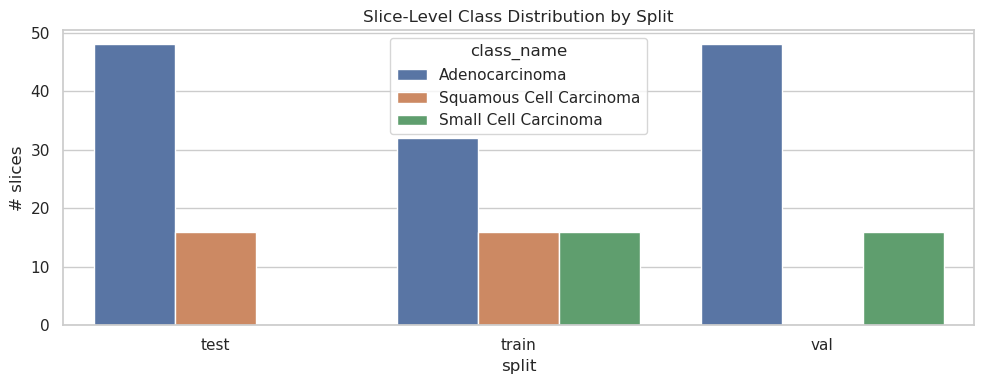

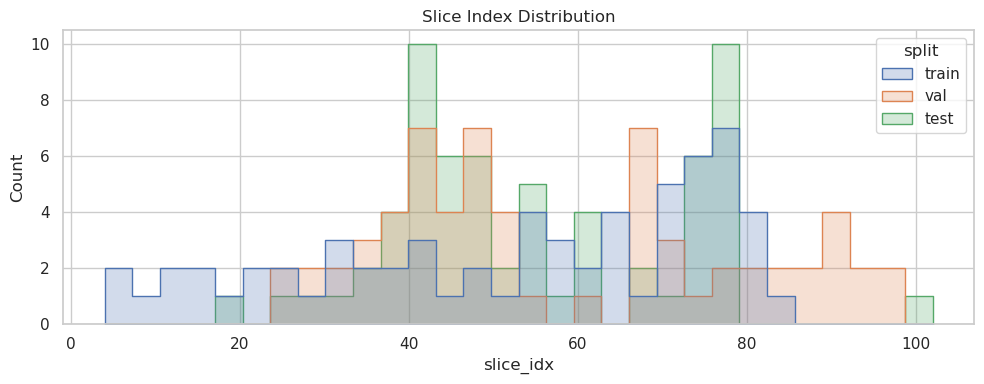

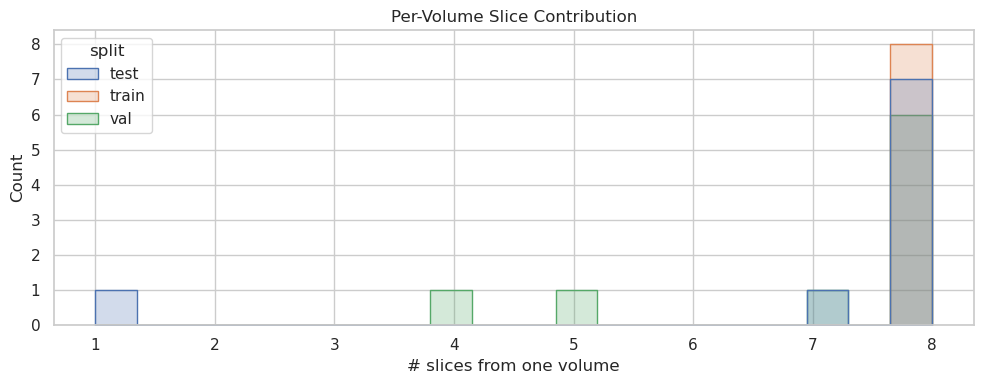

In [17]:
df_meta = pd.DataFrame()
fig_class = None
fig_slice_hist = None
fig_vol_hist = None

if split_to_ds:
    def build_meta_df(entries: List[Dict[str, Any]], split: str) -> pd.DataFrame:
        rows = []
        for e in entries:
            lbl = int(e.get("scan_label", -1))
            rows.append({
                "split": split,
                "image": e.get("image"),
                "tumor_mask": e.get("tumor_mask"),
                "slice_idx": int(e.get("slice_idx", -1)),
                "scan_label": lbl,
                "class_name": CLASS_NAMES[lbl] if 0 <= lbl < len(CLASS_NAMES) else f"Class{lbl}",
                "volume_id": e.get("volume_id") or e.get("image"),
                "patient_id": e.get("patient_id"),
            })
        return pd.DataFrame(rows)

    dfs = []
    for split, ds in split_to_ds.items():
        ds_entries = list(getattr(ds, "data", []))
        print(f"{split:>5}: {len(ds_entries)} entries")
        dfs.append(build_meta_df(ds_entries, split))

    df_meta = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

    display(df_meta.head(8))

    if not df_meta.empty:
        summary = (
            df_meta.groupby("split")
            .agg(
                num_slices=("image", "size"),
                num_volumes=("volume_id", "nunique"),
                num_patients=("patient_id", lambda x: x.nunique(dropna=True)),
                min_slice=("slice_idx", "min"),
                max_slice=("slice_idx", "max"),
            )
            .reset_index()
        )
        display(summary)

        fig_class, ax = plt.subplots(figsize=(10, 4))
        class_df = (
            df_meta.groupby(["split", "class_name"]).size().reset_index(name="count")
        )
        sns.barplot(data=class_df, x="split", y="count", hue="class_name", ax=ax)
        ax.set_title("Slice-Level Class Distribution by Split")
        ax.set_ylabel("# slices")
        plt.tight_layout()

        fig_slice_hist, ax = plt.subplots(figsize=(10, 4))
        sns.histplot(data=df_meta, x="slice_idx", hue="split", bins=30, element="step", stat="count", common_norm=False, ax=ax)
        ax.set_title("Slice Index Distribution")
        plt.tight_layout()

        vol_counts = (
            df_meta.groupby(["split", "volume_id"]).size().reset_index(name="slices_per_volume")
        )
        fig_vol_hist, ax = plt.subplots(figsize=(10, 4))
        sns.histplot(data=vol_counts, x="slices_per_volume", hue="split", bins=20, element="step", stat="count", common_norm=False, ax=ax)
        ax.set_title("Per-Volume Slice Contribution")
        ax.set_xlabel("# slices from one volume")
        plt.tight_layout()
else:
    print("No datasets loaded yet.")

## 3) Visualize Tumor Slice Index Cache and Expansion Logic

This inspects `tumor_slice_index.json`, compares cached indices vs fresh recomputation with `_scan_tumor_slice_indices`, and demonstrates deterministic subsampling when `max_slices_per_volume` is active.

In [18]:
cache_index: Dict[str, Any] = {}

if os.path.isfile(TUMOR_INDEX_PATH):
    with open(TUMOR_INDEX_PATH, "r") as f:
        cache_index = json.load(f)
    print(f"Loaded cache index with {len(cache_index)} masks")

    rows = []
    for k, v in cache_index.items():
        if isinstance(v, dict):
            rows.append({
                "mask_path": k,
                "num_slices": len(v.get("slices", [])),
                "min_pixels": v.get("min_pixels"),
                "mtime": v.get("mtime"),
            })
    df_cache = pd.DataFrame(rows).sort_values("num_slices", ascending=False)
    display(df_cache.head(10))

    # Compare cached vs recomputed for a few masks
    if not df_cache.empty:
        sample_masks = df_cache["mask_path"].dropna().head(5).tolist()
        checks = []
        for mp in sample_masks:
            cached = cache_index.get(mp, {}).get("slices", [])
            recomputed = _scan_tumor_slice_indices(mp, min_pixels=int(CFG["min_tumor_pixels"]))
            checks.append({
                "mask_path": mp,
                "cached_n": len(cached),
                "recomputed_n": len(recomputed),
                "match": cached == recomputed,
            })
        display(pd.DataFrame(checks))

        # Deterministic subsampling demo for one mask with many slices
        if MAX_SLICES is not None and MAX_SLICES > 0:
            candidate = None
            for _, r in df_cache.iterrows():
                if int(r["num_slices"]) > MAX_SLICES:
                    candidate = r["mask_path"]
                    break
            if candidate is not None:
                full_slices = cache_index[candidate]["slices"]
                dummy_entry = [{
                    "image": "dummy_image.nii.gz",
                    "tumor_mask": candidate,
                    "scan_label": 0,
                    "volume_id": "dummy_vol",
                }]
                expanded = _expand_volume_entries_to_slices(
                    dummy_entry,
                    mask_key="tumor_mask",
                    tumor_slice_index={candidate: full_slices},
                    max_slices_per_volume=MAX_SLICES,
                )
                picked = [x["slice_idx"] for x in expanded]
                print(f"Subsampling demo for one mask (cap={MAX_SLICES}):")
                print(f"full ({len(full_slices)}): {full_slices[:20]}{'...' if len(full_slices) > 20 else ''}")
                print(f"picked ({len(picked)}): {picked}")
            else:
                print("No mask has more slices than MAX_SLICES; skipping subsampling demo.")
else:
    print(f"Tumor index cache not found: {TUMOR_INDEX_PATH}")

Loaded cache index with 36 masks


,mask_path,num_slices,min_pixels,mtime
30,/home/data/Lung-PET-CT-Dx-Clean/Lung_Dx-G0018/...,58,1,1.776642e+09
31,/home/data/Lung-PET-CT-Dx-Clean/Lung_Dx-G0018/...,53,1,1.776642e+09
16,/home/data/Lung-PET-CT-Dx-Clean/Lung_Dx-A0220/...,46,1,1.776634e+09
17,/home/data/Lung-PET-CT-Dx-Clean/Lung_Dx-A0220/...,41,1,1.776634e+09
24,/home/data/Lung-PET-CT-Dx-Clean/Lung_Dx-B0036/...,39,1,1.776640e+09
25,/home/data/Lung-PET-CT-Dx-Clean/Lung_Dx-B0036/...,39,1,1.776640e+09
13,/home/data/Lung-PET-CT-Dx-Clean/Lung_Dx-A0179/...,34,1,1.776630e+09
35,/home/data/Lung-PET-CT-Dx-Clean/Lung_Dx-G0036/...,33,1,1.776643e+09
28,/home/data/Lung-PET-CT-Dx-Clean/Lung_Dx-G0010/...,32,1,1.776642e+09
34,/home/data/Lung-PET-CT-Dx-Clean/Lung_Dx-G0036/...,30,1,1.776643e+09


/home/hansstem/anaconda3/envs/sclc/lib/python3.12/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.array Orientation.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


,mask_path,cached_n,recomputed_n,match
0,/home/data/Lung-PET-CT-Dx-Clean/Lung_Dx-G0018/...,58,58,True
1,/home/data/Lung-PET-CT-Dx-Clean/Lung_Dx-G0018/...,53,53,True
2,/home/data/Lung-PET-CT-Dx-Clean/Lung_Dx-A0220/...,46,46,True
3,/home/data/Lung-PET-CT-Dx-Clean/Lung_Dx-A0220/...,41,41,True
4,/home/data/Lung-PET-CT-Dx-Clean/Lung_Dx-B0036/...,39,39,True


Subsampling demo for one mask (cap=8):
full (58): [19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38]...
picked (8): [19, 27, 35, 43, 52, 60, 68, 76]


## 4) Run and Inspect Intermediate Steps of _build_2d_pipeline

This applies each transform stage incrementally and logs shape/type transitions to verify the expected flow ending at `(1, H, W)`.

In [19]:
stage_records: List[Dict[str, Any]] = []
stage_snapshots: Dict[str, Dict[str, Any]] = {}


def to_numpy(x: Any) -> np.ndarray:
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def tensor_info(x: Any) -> Dict[str, Any]:
    arr = to_numpy(x)
    return {
        "shape": tuple(arr.shape),
        "dtype": str(arr.dtype),
        "min": float(np.min(arr)),
        "max": float(np.max(arr)),
        "mean": float(np.mean(arr)),
        "std": float(np.std(arr)),
        "nonzero_frac": float(np.count_nonzero(arr) / arr.size) if arr.size else 0.0,
    }


if split_to_ds and len(train_ds) > 0:
    sample_entry = copy.deepcopy(train_ds.data[0])
    stage_records.append({"stage": "input", **tensor_info(nib.load(sample_entry["image"]).get_fdata(dtype=np.float32))})

    pipeline_list = _build_2d_pipeline(img_size=int(CFG["img_size"]), train=True)
    current = copy.deepcopy(sample_entry)

    watch = {
        "LoadNiftiWithRGBSupportd",
        "Orientationd",
        "Spacingd",
        "SliceSelectd",
        "CropAroundTumord",
        "ScaleIntensityRanged",
        "Resized",
        "SqueezeDimd",
        "NormalizeIntensityd",
        "ToTensord",
    }

    for t in pipeline_list:
        current = t(current)
        name = t.__class__.__name__
        if name in watch and "image" in current:
            rec = {"stage": name, **tensor_info(current["image"])}
            stage_records.append(rec)
            stage_snapshots[name] = copy.deepcopy(current)

    df_stages = pd.DataFrame(stage_records)
    display(df_stages)

    expected = (1, int(CFG["img_size"]), int(CFG["img_size"]))
    final_shape = tuple(to_numpy(current["image"]).shape)
    print(f"Final image shape: {final_shape} | expected: {expected}")
else:
    print("Dataset is not ready; cannot run transform stage introspection yet.")

/home/hansstem/anaconda3/envs/sclc/lib/python3.12/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


,stage,shape,dtype,min,max,mean,std,nonzero_frac
0,input,"(512, 512, 15)",float32,-3024.000000,4995.000000,-9.591671e+02,1154.700562,0.998622
1,LoadNiftiWithRGBSupportd,"(512, 512, 15)",float32,-3024.000000,4995.000000,-9.591671e+02,1154.700562,0.998622
2,Orientationd,"(1, 512, 512, 15)",float32,-3024.000000,4995.000000,-9.591671e+02,1154.700562,0.998622
3,Spacingd,"(1, 350, 350, 36)",float32,-3024.000000,4439.815430,-9.589766e+02,1149.034546,1.000000
4,SliceSelectd,"(1, 350, 350, 1)",float32,-3024.000000,4052.753418,-9.685439e+02,1139.601196,1.000000
5,ScaleIntensityRanged,"(1, 64, 78, 1)",float32,0.009732,0.386656,7.776932e-02,0.037164,1.000000
6,Resized,"(1, 224, 224, 1)",float32,0.016427,0.381878,7.777077e-02,0.036245,1.000000
7,SqueezeDimd,"(1, 224, 224)",float32,0.016427,0.381878,7.777077e-02,0.036245,1.000000
8,NormalizeIntensityd,"(1, 224, 224)",float32,-1.692447,8.390241,7.724275e-08,1.000000,1.000000
9,ToTensord,"(1, 224, 224)",float32,-1.692447,8.390241,7.724275e-08,1.000000,1.000000


Final image shape: (1, 224, 224) | expected: (1, 224, 224)


## 5) Visualize Final Transformed 2D Slices (Train vs Val)

This section compares transformed outputs from train vs val and shows augmentation variability by repeatedly transforming the same source entry with train transforms.

/home/hansstem/anaconda3/envs/sclc/lib/python3.12/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


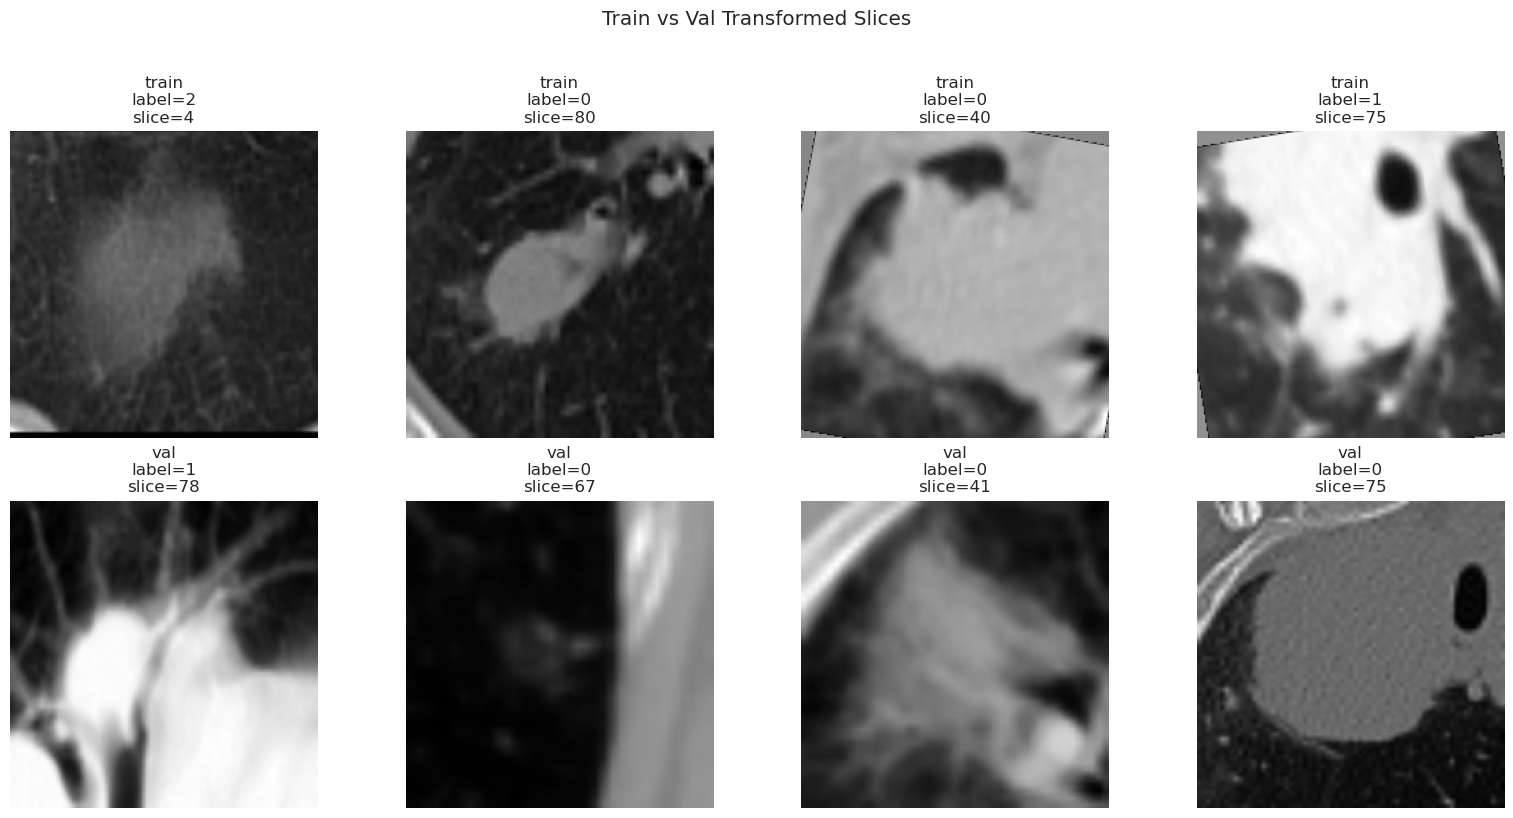

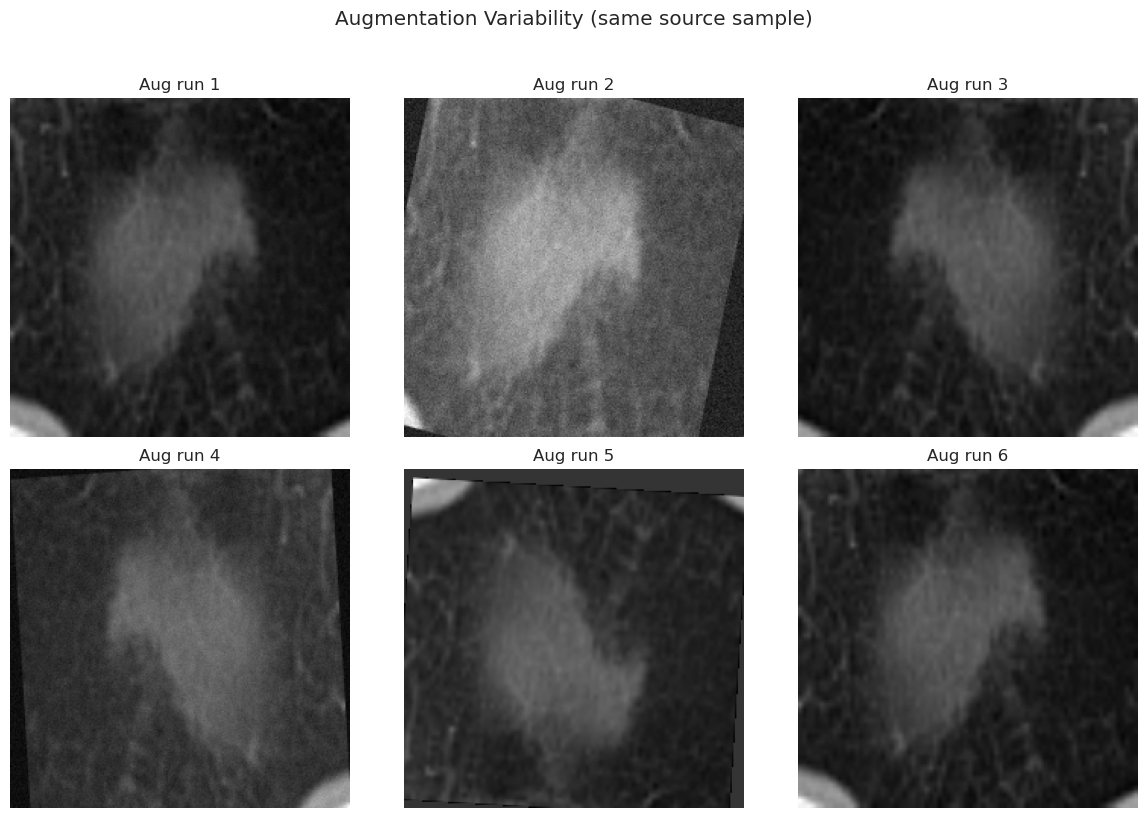

In [20]:
fig_train_val = None
fig_aug = None

if split_to_ds and len(train_ds) > 0 and len(val_ds) > 0:
    n_show = min(4, len(train_ds), len(val_ds))
    train_indices = np.linspace(0, len(train_ds) - 1, n_show).astype(int).tolist()
    val_indices = np.linspace(0, len(val_ds) - 1, n_show).astype(int).tolist()

    fig_train_val, axes = plt.subplots(2, n_show, figsize=(4 * n_show, 8))
    axes = np.atleast_2d(axes)

    for col, i in enumerate(train_indices):
        item = train_ds[i]
        img = to_numpy(item["image"]).squeeze()
        meta = train_ds.data[i]
        axes[0, col].imshow(img, cmap="gray")
        axes[0, col].set_title(
            f"train\nlabel={meta.get('scan_label')}\nslice={meta.get('slice_idx')}"
        )
        axes[0, col].axis("off")

    for col, i in enumerate(val_indices):
        item = val_ds[i]
        img = to_numpy(item["image"]).squeeze()
        meta = val_ds.data[i]
        axes[1, col].imshow(img, cmap="gray")
        axes[1, col].set_title(
            f"val\nlabel={meta.get('scan_label')}\nslice={meta.get('slice_idx')}"
        )
        axes[1, col].axis("off")

    fig_train_val.suptitle("Train vs Val Transformed Slices", y=1.02)
    plt.tight_layout()

    # Same source entry, multiple train-time augmentations
    train_tf = get_train_transforms_2d(img_size=int(CFG["img_size"]))
    source_entry = copy.deepcopy(train_ds.data[0])
    fig_aug, axes = plt.subplots(2, 3, figsize=(12, 8))
    for k, ax in enumerate(axes.flatten()):
        out = train_tf(copy.deepcopy(source_entry))
        arr = to_numpy(out["image"]).squeeze()
        ax.imshow(arr, cmap="gray")
        ax.set_title(f"Aug run {k + 1}")
        ax.axis("off")
    fig_aug.suptitle("Augmentation Variability (same source sample)", y=1.02)
    plt.tight_layout()
else:
    print("Train/val datasets unavailable for visualization.")

## 6) Quantify Transform Effects on Intensity and Geometry

This computes pre/post stats and checks how tumor mask coverage behaves before vs after crop around tumor.

,stage,min,max,mean,std,nonzero_frac
0,after_scale,0.009732,0.386656,7.776932e-02,0.037164,1.0
1,after_normalize,-1.692447,8.390240,-5.838822e-08,1.000000,1.0


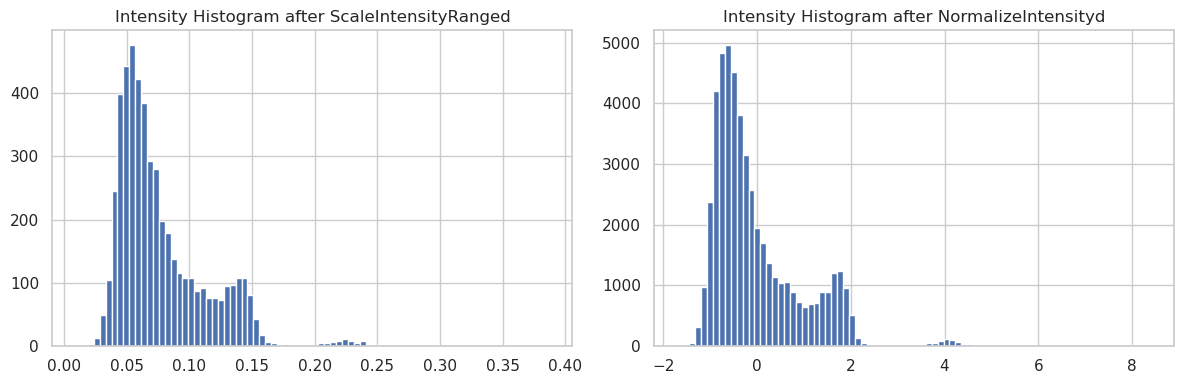

In [21]:
fig_intensity = None
geom_stats: Dict[str, Any] = {}


def mask_bbox(mask_arr: np.ndarray) -> Optional[Tuple[int, int, int, int]]:
    idx = np.argwhere(mask_arr > 0.5)
    if idx.size == 0:
        return None
    y0, x0 = idx.min(axis=0)
    y1, x1 = idx.max(axis=0)
    return int(y0), int(y1), int(x0), int(x1)


if split_to_ds and len(train_ds) > 0:
    entry = copy.deepcopy(train_ds.data[0])
    plist = _build_2d_pipeline(img_size=int(CFG["img_size"]), train=False)
    cur = copy.deepcopy(entry)

    snapshots = {}
    for t in plist:
        cur = t(cur)
        name = t.__class__.__name__
        if name in {"SliceSelectd", "CropAroundTumord", "ScaleIntensityRanged", "NormalizeIntensityd"}:
            snapshots[name] = copy.deepcopy(cur)

    if "SliceSelectd" in snapshots and "CropAroundTumord" in snapshots:
        mask_pre = to_numpy(snapshots["SliceSelectd"]["tumor_mask"]).squeeze()
        mask_post = to_numpy(snapshots["CropAroundTumord"]["tumor_mask"]).squeeze()

        tumor_pix_pre = int((mask_pre > 0.5).sum())
        tumor_pix_post = int((mask_post > 0.5).sum())
        bbox_pre = mask_bbox(mask_pre)
        bbox_post = mask_bbox(mask_post)

        geom_stats = {
            "tumor_pixels_pre_crop": tumor_pix_pre,
            "tumor_pixels_post_crop": tumor_pix_post,
            "retained_fraction": float(tumor_pix_post / max(1, tumor_pix_pre)),
            "bbox_pre": bbox_pre,
            "bbox_post": bbox_post,
            "crop_shape": tuple(mask_post.shape),
        }
        display(pd.Series(geom_stats))

    arr_scale = to_numpy(snapshots["ScaleIntensityRanged"]["image"]).squeeze() if "ScaleIntensityRanged" in snapshots else None
    arr_norm = to_numpy(snapshots["NormalizeIntensityd"]["image"]).squeeze() if "NormalizeIntensityd" in snapshots else None

    if arr_scale is not None and arr_norm is not None:
        stats_df = pd.DataFrame([
            {
                "stage": "after_scale",
                "min": float(arr_scale.min()),
                "max": float(arr_scale.max()),
                "mean": float(arr_scale.mean()),
                "std": float(arr_scale.std()),
                "nonzero_frac": float(np.count_nonzero(arr_scale) / arr_scale.size),
            },
            {
                "stage": "after_normalize",
                "min": float(arr_norm.min()),
                "max": float(arr_norm.max()),
                "mean": float(arr_norm.mean()),
                "std": float(arr_norm.std()),
                "nonzero_frac": float(np.count_nonzero(arr_norm) / arr_norm.size),
            },
        ])
        display(stats_df)

        fig_intensity, ax = plt.subplots(1, 2, figsize=(12, 4))
        ax[0].hist(arr_scale.ravel(), bins=80)
        ax[0].set_title("Intensity Histogram after ScaleIntensityRanged")
        ax[1].hist(arr_norm.ravel(), bins=80)
        ax[1].set_title("Intensity Histogram after NormalizeIntensityd")
        plt.tight_layout()
else:
    print("Dataset unavailable; skipping intensity/geometry quantification.")

## 7) Check Slice-Level Class Balance and Volume Contribution

This compares class balance at two levels:

- Slice-level (what the 2D model directly trains on)
- Volume-level (one vote per volume)

It also highlights dominant volumes and optionally compares capped vs uncapped slice expansion.

,split,volume_id,class_name,num_slices
1,test,/home/data/Lung-PET-CT-Dx-Clean/Lung_Dx-A0129/...,Adenocarcinoma,8
2,test,/home/data/Lung-PET-CT-Dx-Clean/Lung_Dx-A0129/...,Adenocarcinoma,8
8,test,/home/data/Lung-PET-CT-Dx-Clean/Lung_Dx-G0018/...,Squamous Cell Carcinoma,8
3,test,/home/data/Lung-PET-CT-Dx-Clean/Lung_Dx-A0191/...,Adenocarcinoma,8
5,test,/home/data/Lung-PET-CT-Dx-Clean/Lung_Dx-A0234/...,Adenocarcinoma,8
6,test,/home/data/Lung-PET-CT-Dx-Clean/Lung_Dx-A0234/...,Adenocarcinoma,8
9,train,/home/data/Lung-PET-CT-Dx-Clean/Lung_Dx-A0148/...,Adenocarcinoma,8
7,test,/home/data/Lung-PET-CT-Dx-Clean/Lung_Dx-G0018/...,Squamous Cell Carcinoma,8
11,train,/home/data/Lung-PET-CT-Dx-Clean/Lung_Dx-A0179/...,Adenocarcinoma,8
10,train,/home/data/Lung-PET-CT-Dx-Clean/Lung_Dx-A0148/...,Adenocarcinoma,8


Split 'train': 242 patients.
  12 images (12 w/ masks), class distribution: {2: 6, 0: 4, 1: 2}
Split 'val': 52 patients.
  12 images (12 w/ masks), class distribution: {1: 2, 0: 8, 2: 2}
Split 'test': 53 patients.
  12 images (12 w/ masks), class distribution: {2: 2, 0: 10}
[2D lung_pet_ct_dx train] 64 slices from 12 volumes, classes={2: 16, 0: 32, 1: 16}
[2D lung_pet_ct_dx val] 64 slices from 12 volumes, classes={1: 16, 0: 48}
[2D lung_pet_ct_dx test] 64 slices from 12 volumes, classes={2: 16, 0: 48}
Split 'train': 242 patients.
  12 images (12 w/ masks), class distribution: {2: 6, 0: 4, 1: 2}
Split 'val': 52 patients.
  12 images (12 w/ masks), class distribution: {1: 2, 0: 8, 2: 2}
Split 'test': 53 patients.
  12 images (12 w/ masks), class distribution: {2: 2, 0: 10}
[2D lung_pet_ct_dx train] 64 slices from 12 volumes, classes={2: 59, 0: 5}
[2D lung_pet_ct_dx val] 64 slices from 12 volumes, classes={1: 38, 0: 26}
[2D lung_pet_ct_dx test] 64 slices from 12 volumes, classes={2: 64}


,split,setting,num_slices
0,train,capped,64
1,train,uncapped,64
2,val,capped,64
3,val,uncapped,64
4,test,capped,64
5,test,uncapped,64


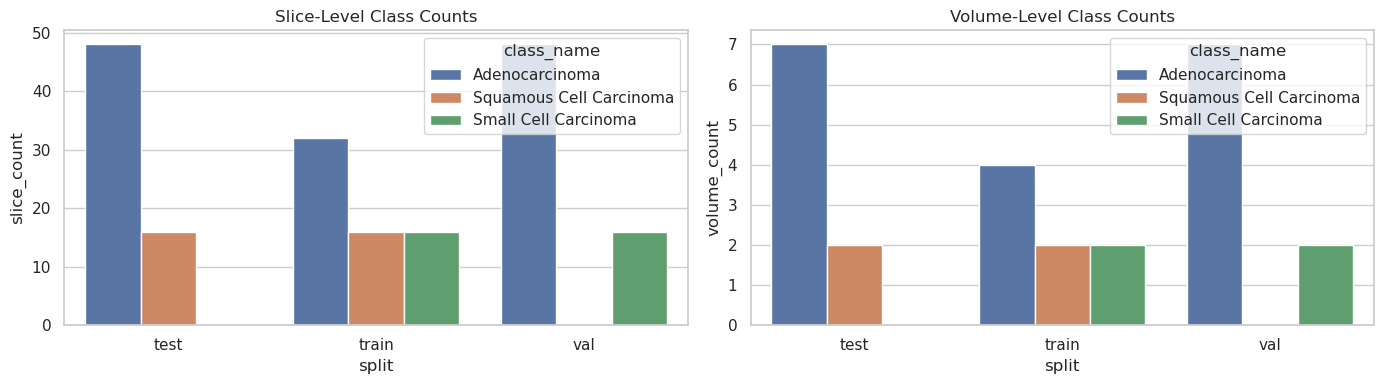

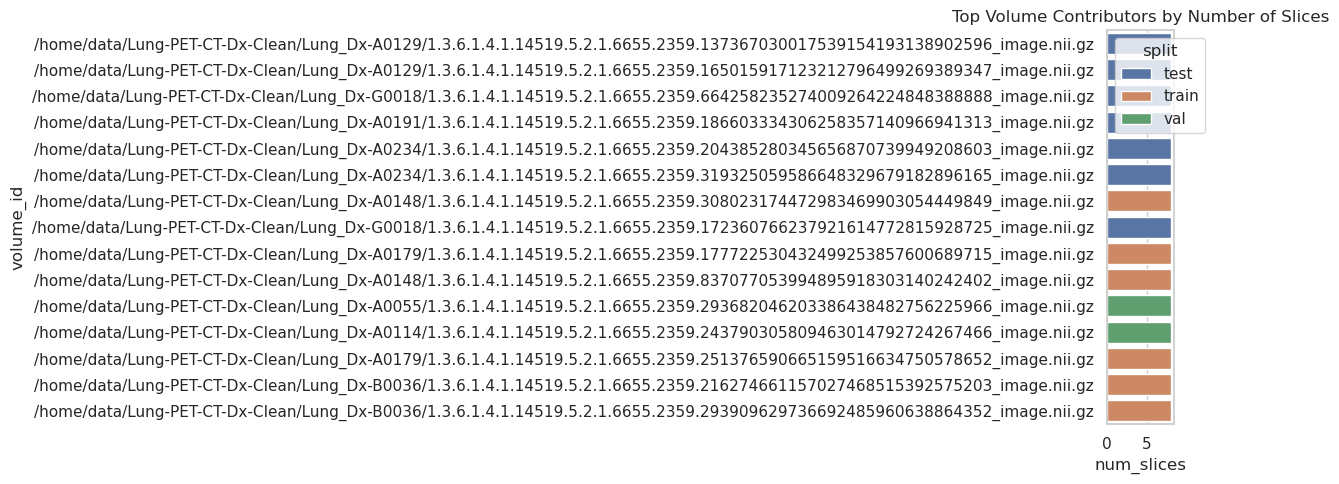

In [22]:
fig_balance = None
fig_top_vols = None
compare_cap_df = pd.DataFrame()

if not df_meta.empty:
    slice_counts = (
        df_meta.groupby(["split", "class_name"]).size().reset_index(name="slice_count")
    )

    vol_label_df = (
        df_meta.sort_values("slice_idx")
        .drop_duplicates(["split", "volume_id"])[["split", "volume_id", "class_name"]]
    )
    volume_counts = (
        vol_label_df.groupby(["split", "class_name"]).size().reset_index(name="volume_count")
    )

    fig_balance, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.barplot(data=slice_counts, x="split", y="slice_count", hue="class_name", ax=axes[0])
    axes[0].set_title("Slice-Level Class Counts")
    sns.barplot(data=volume_counts, x="split", y="volume_count", hue="class_name", ax=axes[1])
    axes[1].set_title("Volume-Level Class Counts")
    plt.tight_layout()

    top_vols = (
        df_meta.groupby(["split", "volume_id", "class_name"]).size().reset_index(name="num_slices")
        .sort_values("num_slices", ascending=False)
        .head(15)
    )
    display(top_vols)

    fig_top_vols, ax = plt.subplots(figsize=(12, 5))
    sns.barplot(data=top_vols, x="num_slices", y="volume_id", hue="split", orient="h", ax=ax)
    ax.set_title("Top Volume Contributors by Number of Slices")
    ax.set_ylabel("volume_id")
    plt.tight_layout()

    # Optional cap-vs-no-cap comparison using split builders (metadata only)
    if os.path.isdir(CFG["data_path"]):
        builder_kwargs = dict(
            data_path=CFG["data_path"],
            val_frac=float(CFG["val_frac"]),
            test_frac=float(CFG["test_frac"]),
            seed=int(CFG["seed"]),
            testing=bool(CFG["testing"]),
            min_tumor_pixels=int(CFG["min_tumor_pixels"]),
        )

        try:
            if CFG["dataset_type"] == "big_lunge":
                capped = get_biglunge_2d_data_list(
                    csv_path=CFG["csv_path"],
                    cache_root=CACHE_ROOT,
                    tumor_mask_suffix=CFG["tumor_mask_suffix"],
                    max_slices_per_volume=MAX_SLICES,
                    **builder_kwargs,
                )
                uncapped = get_biglunge_2d_data_list(
                    csv_path=CFG["csv_path"],
                    cache_root=CACHE_ROOT,
                    tumor_mask_suffix=CFG["tumor_mask_suffix"],
                    max_slices_per_volume=None,
                    **builder_kwargs,
                )
            else:
                capped = get_lung_pet_ct_dx_2d_data_list(
                    cache_root=CACHE_ROOT,
                    max_slices_per_volume=MAX_SLICES,
                    **builder_kwargs,
                )
                uncapped = get_lung_pet_ct_dx_2d_data_list(
                    cache_root=CACHE_ROOT,
                    max_slices_per_volume=None,
                    **builder_kwargs,
                )

            rows = []
            for split in ("train", "val", "test"):
                rows.append({"split": split, "setting": "capped", "num_slices": len(capped.get(split, []))})
                rows.append({"split": split, "setting": "uncapped", "num_slices": len(uncapped.get(split, []))})
            compare_cap_df = pd.DataFrame(rows)
            display(compare_cap_df)
        except Exception as e:
            print(f"Cap-vs-uncapped comparison skipped due to error: {e}")
else:
    print("Metadata table empty; cannot compute balance analyses.")

## 8) Validate Collation with simple_collate_fn_2d

This checks that batched outputs are exactly `(images, labels, meta)` with expected tensor shapes and metadata keys.

In [23]:
batch_diag: Dict[str, Any] = {}

if train_ds is not None and len(train_ds) > 0:
    loader = DataLoader(
        train_ds,
        batch_size=int(CFG["batch_size"]),
        shuffle=True,
        num_workers=int(CFG["num_workers"]),
        collate_fn=simple_collate_fn_2d,
    )

    images, labels, meta = next(iter(loader))

    batch_diag = {
        "images_shape": tuple(images.shape),
        "images_dtype": str(images.dtype),
        "labels_shape": tuple(labels.shape),
        "labels_dtype": str(labels.dtype),
        "meta_len": len(meta),
        "meta_keys": sorted(list(meta[0].keys())) if meta else [],
        "unique_volume_ids_in_batch": len({m.get("volume_id") for m in meta}),
        "unique_patient_ids_in_batch": len({m.get("patient_id") for m in meta if m.get("patient_id") is not None}),
    }

    print(pd.Series(batch_diag))
    display(pd.DataFrame(meta[: min(5, len(meta))]))
else:
    print("Train dataset unavailable; skipping collate diagnostics.")

images_shape                                     (8, 1, 224, 224)
images_dtype                                        torch.float32
labels_shape                                                 (8,)
labels_dtype                                          torch.int64
meta_len                                                        8
meta_keys                      [patient_id, slice_idx, volume_id]
unique_volume_ids_in_batch                                      6
unique_patient_ids_in_batch                                     4
dtype: object


,volume_id,patient_id,slice_idx
0,/home/data/Lung-PET-CT-Dx-Clean/Lung_Dx-A0179/...,Lung_Dx-A0179,55
1,/home/data/Lung-PET-CT-Dx-Clean/Lung_Dx-A0148/...,Lung_Dx-A0148,75
2,/home/data/Lung-PET-CT-Dx-Clean/Lung_Dx-A0148/...,Lung_Dx-A0148,77
3,/home/data/Lung-PET-CT-Dx-Clean/Lung_Dx-G0010/...,Lung_Dx-G0010,31
4,/home/data/Lung-PET-CT-Dx-Clean/Lung_Dx-G0010/...,Lung_Dx-G0010,14


## 9) Smoke-Test Model Forward Pass and Batch Diagnostics

Try loading a project 2D model and run a few batches through it (`return_segmentation=False`).
If model construction fails (for example missing pretrained weights), fallback to a minimal 2D CNN just for shape/probability sanity checks.

Model used: efficientnet_b0_2d
Collected predictions from 32 slices
Mean softmax by class:
  Adenocarcinoma          : 0.0698
  Small Cell Carcinoma    : 0.7281
  Squamous Cell Carcinoma : 0.2021


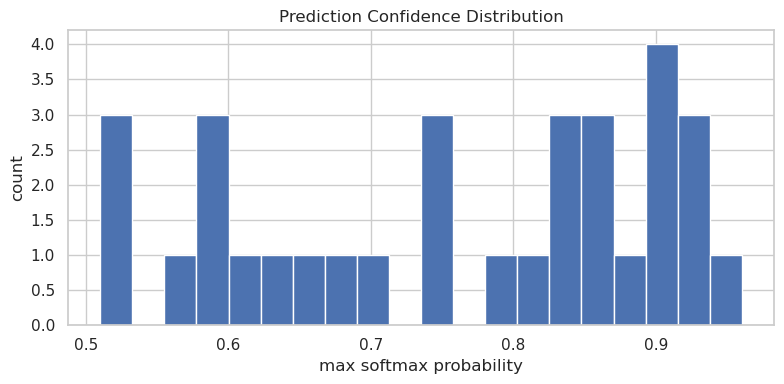

In [24]:
model = None
model_name_used = None
pred_confidences: List[float] = []
prob_rows: List[np.ndarray] = []
fig_conf = None

if train_ds is not None and len(train_ds) > 0:
    device = torch.device(CFG["device"])

    try:
        model = get_sclc_model(model_type="efficientnet_b0_2d", checkpoint_path="")
        model_name_used = "efficientnet_b0_2d"
    except Exception as e:
        print(f"Project model load failed, using fallback TinyNet. Error: {e}")

        class TinyNet(torch.nn.Module):
            def __init__(self, num_classes: int = 3):
                super().__init__()
                self.net = torch.nn.Sequential(
                    torch.nn.Conv2d(1, 16, kernel_size=3, padding=1),
                    torch.nn.ReLU(inplace=True),
                    torch.nn.MaxPool2d(2),
                    torch.nn.Conv2d(16, 32, kernel_size=3, padding=1),
                    torch.nn.ReLU(inplace=True),
                    torch.nn.AdaptiveAvgPool2d((1, 1)),
                )
                self.fc = torch.nn.Linear(32, num_classes)

            def forward(self, x, return_segmentation: bool = False):
                h = self.net(x).flatten(1)
                return self.fc(h)

        model = TinyNet(num_classes=3)
        model_name_used = "TinyNetFallback"

    model = model.to(device).eval()

    smoke_loader = DataLoader(
        train_ds,
        batch_size=int(CFG["batch_size"]),
        shuffle=False,
        num_workers=int(CFG["num_workers"]),
        collate_fn=simple_collate_fn_2d,
    )

    with torch.no_grad():
        for bidx, (images, labels, meta) in enumerate(smoke_loader):
            if bidx >= int(CFG["max_batches_eval"]):
                break
            images = images.to(device)

            try:
                logits = model(images, return_segmentation=False)
            except TypeError:
                logits = model(images)

            probs = torch.softmax(logits, dim=1).detach().cpu().numpy()
            prob_rows.extend(list(probs))
            pred_confidences.extend(list(np.max(probs, axis=1)))

    print(f"Model used: {model_name_used}")
    print(f"Collected predictions from {len(prob_rows)} slices")

    if pred_confidences:
        fig_conf, ax = plt.subplots(figsize=(8, 4))
        ax.hist(pred_confidences, bins=20)
        ax.set_title("Prediction Confidence Distribution")
        ax.set_xlabel("max softmax probability")
        ax.set_ylabel("count")
        plt.tight_layout()

        probs_np = np.asarray(prob_rows)
        mean_probs = probs_np.mean(axis=0)
        print("Mean softmax by class:")
        for i, p in enumerate(mean_probs):
            cname = CLASS_NAMES[i] if i < len(CLASS_NAMES) else f"Class{i}"
            print(f"  {cname:<24}: {p:.4f}")
else:
    print("Dataset unavailable; skipping model smoke test.")

## 10) Reproduce Volume/Patient Aggregation Logic from validate_epoch_2d

This recreates notebook-side aggregation parity checks:

1. Slice-level predictions from softmax.
2. Mean-probability per volume, then argmax.
3. Mean-probability per patient (equal weight per volume), then argmax.

Metrics are computed with the same helper used in training (`_compute_classification_metrics`).

In [25]:
agg_summary = pd.DataFrame()
agg_metrics: Dict[str, Any] = {}

if model is not None and val_ds is not None and len(val_ds) > 0:
    device = next(model.parameters()).device
    val_loader = DataLoader(
        val_ds,
        batch_size=int(CFG["batch_size"]),
        shuffle=False,
        num_workers=int(CFG["num_workers"]),
        collate_fn=simple_collate_fn_2d,
    )

    slice_targets: List[int] = []
    slice_preds: List[int] = []

    volume_prob_sum: Dict[str, np.ndarray] = {}
    volume_slice_count: Dict[str, int] = {}
    volume_label: Dict[str, int] = {}
    volume_patient: Dict[str, Any] = {}

    with torch.no_grad():
        for bidx, (images, labels, meta) in enumerate(val_loader):
            if bidx >= int(CFG["max_batches_eval"]):
                break

            images = images.to(device)
            labels = labels.to(device)
            try:
                logits = model(images, return_segmentation=False)
            except TypeError:
                logits = model(images)

            probs = torch.softmax(logits, dim=1).cpu().numpy()
            preds = probs.argmax(axis=1)
            tgts = labels.cpu().numpy()

            slice_preds.extend([int(p) for p in preds])
            slice_targets.extend([int(t) for t in tgts])

            for i, m in enumerate(meta):
                vid = m["volume_id"]
                if vid not in volume_prob_sum:
                    volume_prob_sum[vid] = np.zeros(probs.shape[1], dtype=np.float64)
                    volume_slice_count[vid] = 0
                    volume_label[vid] = int(tgts[i])
                    volume_patient[vid] = m.get("patient_id")
                volume_prob_sum[vid] += probs[i]
                volume_slice_count[vid] += 1

    volume_ids = list(volume_prob_sum.keys())
    volume_targets: List[int] = []
    volume_preds: List[int] = []
    volume_probs: List[np.ndarray] = []

    for vid in volume_ids:
        mp = volume_prob_sum[vid] / max(1, volume_slice_count[vid])
        volume_probs.append(mp)
        volume_preds.append(int(mp.argmax()))
        volume_targets.append(int(volume_label[vid]))

    patient_prob_sum: Dict[Any, np.ndarray] = {}
    patient_volume_count: Dict[Any, int] = {}
    patient_label: Dict[Any, int] = {}

    for i, vid in enumerate(volume_ids):
        pid = volume_patient.get(vid)
        key = pid if pid is not None else f"__vol__:{vid}"
        if key not in patient_prob_sum:
            patient_prob_sum[key] = np.zeros_like(volume_probs[i], dtype=np.float64)
            patient_volume_count[key] = 0
            patient_label[key] = volume_label[vid]
        patient_prob_sum[key] += volume_probs[i]
        patient_volume_count[key] += 1

    patient_keys = list(patient_prob_sum.keys())
    patient_targets: List[int] = []
    patient_preds: List[int] = []
    for key in patient_keys:
        mp = patient_prob_sum[key] / max(1, patient_volume_count[key])
        patient_preds.append(int(mp.argmax()))
        patient_targets.append(int(patient_label[key]))

    slice_m = _compute_classification_metrics(slice_targets, slice_preds)
    vol_m = _compute_classification_metrics(volume_targets, volume_preds)
    pat_m = _compute_classification_metrics(patient_targets, patient_preds)

    agg_summary = pd.DataFrame([
        {"level": "slice", "n": len(slice_targets), "accuracy": slice_m["accuracy"], "macro_f1": slice_m["macro_f1"]},
        {"level": "volume", "n": len(volume_targets), "accuracy": vol_m["accuracy"], "macro_f1": vol_m["macro_f1"]},
        {"level": "patient", "n": len(patient_targets), "accuracy": pat_m["accuracy"], "macro_f1": pat_m["macro_f1"]},
    ])
    display(agg_summary)

    agg_metrics = {
        "slice": {"n": len(slice_targets), "accuracy": float(slice_m["accuracy"]), "macro_f1": float(slice_m["macro_f1"])},
        "volume": {"n": len(volume_targets), "accuracy": float(vol_m["accuracy"]), "macro_f1": float(vol_m["macro_f1"])},
        "patient": {"n": len(patient_targets), "accuracy": float(pat_m["accuracy"]), "macro_f1": float(pat_m["macro_f1"])},
    }
else:
    print("Model or val dataset unavailable; skipping aggregation parity check.")

,level,n,accuracy,macro_f1
0,slice,32,0.500000,0.333333
1,volume,5,0.400000,0.285714
2,patient,3,0.333333,0.250000


## 11) Export Debug Artifacts (figures, sample table, sanity JSON)

This writes reproducible artifacts to an output folder for later comparison across runs.

In [26]:
EXPORT_DIR = Path("output/2d_data_expl")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

saved_files: List[str] = []

fig_map = {
    "class_distribution.png": fig_class,
    "slice_index_hist.png": fig_slice_hist,
    "volume_slice_hist.png": fig_vol_hist,
    "train_vs_val_examples.png": fig_train_val,
    "augmentation_variability.png": fig_aug,
    "intensity_histograms.png": fig_intensity,
    "balance_slice_vs_volume.png": fig_balance,
    "top_volume_contributors.png": fig_top_vols,
    "confidence_histogram.png": fig_conf,
}

for fname, fig in fig_map.items():
    if fig is not None:
        out = EXPORT_DIR / fname
        fig.savefig(out, dpi=160, bbox_inches="tight")
        saved_files.append(str(out))

if not df_meta.empty:
    sample_meta_path = EXPORT_DIR / "sample_metadata.csv"
    df_meta.head(500).to_csv(sample_meta_path, index=False)
    saved_files.append(str(sample_meta_path))

slice_class_counts_records = []
if not df_meta.empty:
    tmp = df_meta.groupby(["split", "scan_label"]).size().reset_index(name="count")
    for _, r in tmp.iterrows():
        lbl = int(r["scan_label"])
        slice_class_counts_records.append({
            "split": str(r["split"]),
            "scan_label": lbl,
            "class_name": CLASS_NAMES[lbl] if 0 <= lbl < len(CLASS_NAMES) else f"Class{lbl}",
            "count": int(r["count"]),
        })

summary = {
    "config": CFG,
    "split_sizes": {k: int(len(v)) for k, v in split_to_ds.items()} if split_to_ds else {},
    "slice_level_class_counts": slice_class_counts_records,
    "batch_diag": batch_diag,
    "geometry_stats": geom_stats,
    "aggregation_metrics": agg_metrics,
    "saved_files": saved_files,
}

summary_path = EXPORT_DIR / "sanity_summary.json"
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)
saved_files.append(str(summary_path))

print("Saved artifacts:")
for p in saved_files:
    print(f"- {p}")

Saved artifacts:
- output/2d_data_expl/class_distribution.png
- output/2d_data_expl/slice_index_hist.png
- output/2d_data_expl/volume_slice_hist.png
- output/2d_data_expl/train_vs_val_examples.png
- output/2d_data_expl/augmentation_variability.png
- output/2d_data_expl/intensity_histograms.png
- output/2d_data_expl/balance_slice_vs_volume.png
- output/2d_data_expl/top_volume_contributors.png
- output/2d_data_expl/confidence_histogram.png
- output/2d_data_expl/sample_metadata.csv
- output/2d_data_expl/sanity_summary.json


## 12) Next Checks

If you want to deepen this exploration, useful next steps are:

1. Run with `testing=False` and compare stability of distributions.
2. Repeat with `DATASET_TYPE='lung_pet_ct_dx'` and inspect multi-scan patient effects.
3. Sweep `max_slices_per_volume` (for example 4, 8, 12, uncapped) and track how class balance and dominant volumes shift.
4. Plug in a trained 2D checkpoint and compare slice/volume/patient metrics from this notebook against `validate_epoch_2d` logs.